In [1]:
# QSS 20 Final Project
# Cooper Hindshaw

# Project:
# Asset thresholds and unconditional cash transfers in rural Kenya

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_stata("dataverse_files/UCT_FINAL_CLEAN.dta")

In [4]:
df.shape
df.head()

,surveyid,femaleres,maleres,village,treat,spillover,purecontrol,control_village,treatXfemalerec,treatXmalerec,...,m_cesd11,m_cesd12,m_cesd13,m_cesd14,m_cesd15,m_cesd16,m_cesd17,m_cesd18,m_cesd19,m_cesd20
0,106540326.0,0,1.0,74,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,2.0,3.0,1.0,1.0,2.0,1.0,3.0,3.0,2.0
1,106540326.0,1,0.0,74,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,2.0,3.0,1.0,1.0,2.0,1.0,3.0,3.0,2.0
2,106769148.0,0,1.0,55,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0
3,106769148.0,1,0.0,55,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,1.0,1.0
4,106799419.0,0,1.0,71,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,1.0,2.0


In [5]:

treatment_vars = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["treat", "spillover", "control", "large", "lump", "monthly"])
]

treatment_vars

['treat',
 'spillover',
 'purecontrol',
 'control_village',
 'treatXfemalerec',
 'treatXmalerec',
 'treatXfemalerecXmarried',
 'treatXmalerecXmarried',
 'treatXsinglerec',
 'treatXlump',
 'treatXmonthly',
 'treatXlarge',
 'treatXsmall',
 'treatXmalerecXlump',
 'treatXmalerecXsmall',
 'treatXlumpXsmall',
 'treatXmalerecXlumpXsmall',
 'treatXmalerecXlarge',
 'treatXlumpXlarge',
 'treatXmalerecXlumpXlarge',
 'treatXmalerecXmonthly',
 'treatXmonthlyXsmall',
 'treatXmalerecXmonthlyXsmall',
 'treatXmonthlyXlarge',
 'treatXmalerecXmonthlyXlarge',
 'treatXfemalerecXlump',
 'treatXfemalerecXsmall',
 'treatXfemalerecXlumpXsmall',
 'treatXfemalerecXlarge',
 'treatXfemalerecXlumpXlarge',
 'treatXfemalerecXmonthly',
 'treatXfemalerecXmonthlyXsmall',
 'treatXfemalerecXmonthlyXlarge',
 'treatXmaleres',
 'treatXfemaleres',
 'treatXlargeXmaleres',
 'treatXlargeXfemaleres',
 'treatXsmallXmaleres',
 'treatXsmallXfemaleres',
 'treatXlumpXmaleres',
 'treatXlumpXfemaleres',
 'treatXmonthlyXmaleres',
 'treat

In [6]:
asset_vars = [
    col for col in df.columns
    if any(word in col.lower()
           for word in ["asset", "wealth", "durable", "livestock",
                        "cow", "goat", "land", "roof", "house"])
]

asset_vars

['asset_total_ppp0',
 'asset_total_ppp_full0',
 'asset_total_ppp_miss0',
 'asset_total_ppp1',
 'cons_nondurable_ppp0',
 'cons_nondurable_ppp_full0',
 'cons_nondurable_ppp_miss0',
 'cons_nondurable_ppp1',
 'asset_lntotal_ppp0',
 'asset_lntotal_ppp_full0',
 'asset_lntotal_ppp_miss0',
 'asset_lntotal_ppp1',
 'cons_lnnondurable_ppp0',
 'cons_lnnondurable_ppp_full0',
 'cons_lnnondurable_ppp_miss0',
 'cons_lnnondurable_ppp1',
 'asset_total_noroof_ppp0',
 'asset_total_noroof_ppp_full0',
 'asset_total_noroof_ppp_miss0',
 'asset_total_noroof_ppp1',
 'asset_livestock_ppp0',
 'asset_livestock_ppp_full0',
 'asset_livestock_ppp_miss0',
 'asset_livestock_ppp1',
 'asset_cows_ppp0',
 'asset_cows_ppp_full0',
 'asset_cows_ppp_miss0',
 'asset_cows_ppp1',
 'asset_smalllivestock_ppp0',
 'asset_smalllivestock_ppp_full0',
 'asset_smalllivestock_ppp_miss0',
 'asset_smalllivestock_ppp1',
 'asset_birds_ppp0',
 'asset_birds_ppp_full0',
 'asset_birds_ppp_miss0',
 'asset_birds_ppp1',
 'asset_durable_ppp0',
 'asset

In [9]:
df["surveyid"].nunique()

1440

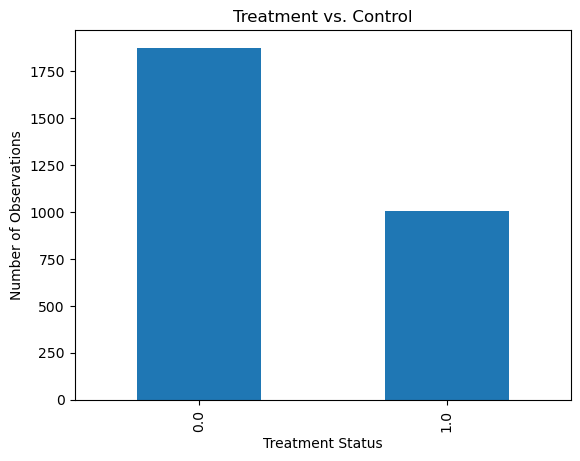

In [10]:
df["treat"].value_counts().plot(kind="bar")

plt.xlabel("Treatment Status")
plt.ylabel("Number of Observations")
plt.title("Treatment vs. Control")

plt.show()

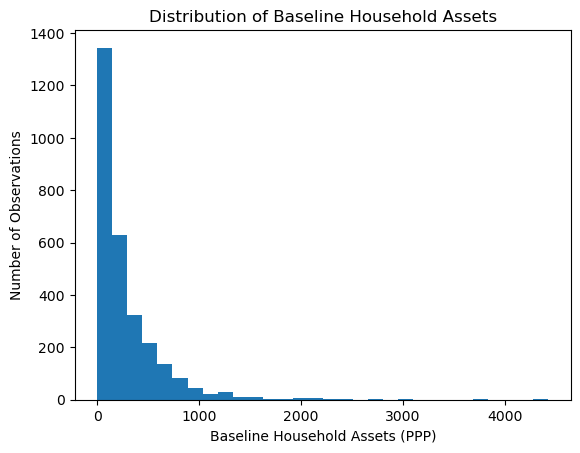

In [14]:
df["asset_total_ppp0"].plot(kind="hist", bins=30)

plt.xlabel("Baseline Household Assets (PPP)")
plt.ylabel("Number of Observations")
plt.title("Distribution of Baseline Household Assets")

plt.show()